In [1]:
import numpy as np

# Initialize parameters

In [2]:
n_clusters = 3 #something that you choose
max_iter = 300 #tells python to stop computing after certain iterations

#random seed
seed = 1989

## Helper functions

In [3]:
def initialize_centroids(X, 
                         n_clusters=n_clusters, 
                         random_state=seed):

    #Make this reproducible
    np.random.seed(seed)

    # This would be the random index of the centroid we will be choosing at the start of the iteration

    random_idx = np.random.permutation(X.shape[0])
    centroids = X[random_idx[:n_clusters]]
    return centroids

In [4]:
def compute_distances(X, centroids):
    distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
    return distances

In [5]:
def update_centroids(X, labels, n_clusters):
    centroids = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])
    return centroids

In [6]:
def compute_sse(X, labels, centroids):
    distances = np.sqrt(((X-centroids[labels])**2).sum(axis=1))
    return np.sum(distances**2)

## Fitting K-Means

In [7]:
# Call the helper functions in this code
def fit_kmeans(X,
               n_clusters=n_clusters,
               max_iter=max_iter,
               random_state=seed):

    # First part: choose a centroid
    centroids = initialize_centroids(X, n_clusters, random_state)
    print(f"[init] Starting centroids (shape {centroids.shape}):\n{centroids}\n")

    inertia = None

    # Loop for the iterations
    for i in range(max_iter):
        print(f"--- Iteration {i} ---")

        distances = compute_distances(X, centroids)
        labels = np.argmin(distances, axis=0)

        # Show how many points landed in each cluster
        counts = np.bincount(labels, minlength=n_clusters)
        print(f"  Cluster sizes: {dict(enumerate(counts))}")

        # Update centroids
        new_centroids = update_centroids(X, labels, n_clusters)

        # How much did centroids move this round?
        shift = np.linalg.norm(new_centroids - centroids)
        print(f"  Centroid shift (L2 norm): {shift:.6f}")

        # Check if the centroids have changed
        if np.all(centroids == new_centroids):
            print(f"  Centroids unchanged -> converged at iteration {i}")
            centroids = new_centroids
            break

        centroids = new_centroids

        # Compute the SSE
        inertia = compute_sse(X, labels, centroids)
        print(f"  SSE after this update: {inertia:.4f}\n")

    else:
        print(f"  Reached max_iter={max_iter} without full convergence\n")

    print(f"[done] Final SSE: {inertia}")
    print(f"[done] Final centroids:\n{centroids}")

    return centroids, labels, inertia

## Test the code with Iris dataset

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans as SKLearnKmeans

In [9]:
# Load Iris dataset
data = load_iris()

In [10]:
X = data.data

# Customized k-means

In [11]:
customized_centroids, customized_labels, customized_inertia = fit_kmeans(X)

[init] Starting centroids (shape (3, 4)):
[[5.6 2.8 4.9 2. ]
 [5.2 2.7 3.9 1.4]
 [7.6 3.  6.6 2.1]]

--- Iteration 0 ---
  Cluster sizes: {0: np.int64(53), 1: np.int64(77), 2: np.int64(20)}
  Centroid shift (L2 norm): 2.083919
  SSE after this update: 199.9120

--- Iteration 1 ---
  Cluster sizes: {0: np.int64(71), 1: np.int64(57), 2: np.int64(22)}
  Centroid shift (L2 norm): 0.799552
  SSE after this update: 106.6658

--- Iteration 2 ---
  Cluster sizes: {0: np.int64(70), 1: np.int64(52), 2: np.int64(28)}
  Centroid shift (L2 norm): 0.340099
  SSE after this update: 87.0098

--- Iteration 3 ---
  Cluster sizes: {0: np.int64(66), 1: np.int64(50), 2: np.int64(34)}
  Centroid shift (L2 norm): 0.226122
  SSE after this update: 80.0324

--- Iteration 4 ---
  Cluster sizes: {0: np.int64(63), 1: np.int64(50), 2: np.int64(37)}
  Centroid shift (L2 norm): 0.087060
  SSE after this update: 79.0540

--- Iteration 5 ---
  Cluster sizes: {0: np.int64(62), 1: np.int64(50), 2: np.int64(38)}
  Centro

In [12]:
customized_centroids

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

## SKLearn Clustering

In [13]:
sklearn_kmeans = SKLearnKmeans(n_clusters=n_clusters, random_state=seed)
sklearn_kmeans.fit(X)

KMeans(n_clusters=3, random_state=1989)

# Visualization

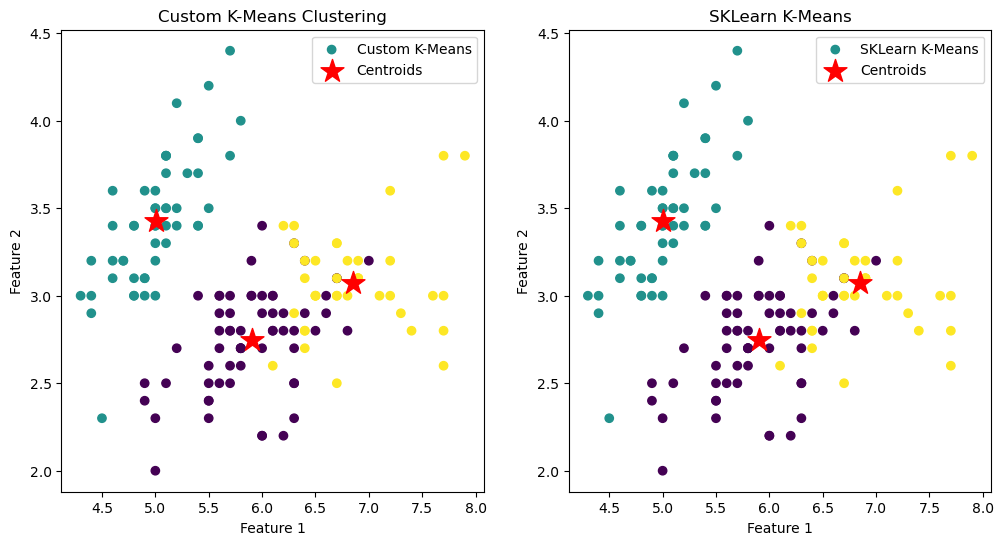

In [14]:
plt.figure(figsize=(12 , 6))

#Customized K-Means
plt.subplot(1, 2, 1)

# Plotting the points
plt.scatter(X[:, 0], X[:, 1], c=customized_labels, cmap='viridis', marker='o', label="Custom K-Means")

# Plot the centroids
plt.scatter(customized_centroids[:, 0], customized_centroids[:, 1], c='red', s=300, marker='*', label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.title("Custom K-Means Clustering")

# SKLearn K-Means
plt.subplot(1, 2, 2)
# Plotting the points
plt.scatter(X[:, 0], X[:, 1], c=sklearn_kmeans.labels_, cmap='viridis', marker='o', label="SKLearn K-Means")
#Plot the centroids
plt.scatter(sklearn_kmeans.cluster_centers_[:, 0], sklearn_kmeans.cluster_centers_[:, 1], c='red', s=300, marker='*', label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("SKLearn K-Means")
plt.legend()
plt.show()